In [5]:
import sys
from pathlib import Path
import os
from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env file

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from infra.db.database_utils import DatabaseEngine, get_postgres_db_engine
import pandas as pd
engine = get_postgres_db_engine()

data = engine.get_records(table_name="training_data_labeled")

data.describe()

,tBodyAcc-mean()-X,tBodyAcc-std()-X,tBodyAcc-min()-X,tBodyAcc-max()-X,tBodyAcc-energy()-X,tBodyAcc-entropy()-X,tBodyAcc-mean()-Y,tBodyAcc-std()-Y,tBodyAcc-min()-Y,tBodyAcc-max()-Y,...,fBodyAccJerk-std()-Z,fBodyAccJerk-energy()-Z,fBodyAccJerk-entropy()-Z,fBodyAccJerk-meanFreq()-Z,fBodyAccMag-mean(),fBodyAccMag-std(),fBodyAccMag-energy(),fBodyAccMag-entropy(),fBodyAccMag-meanFreq(),timestamp
count,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,...,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,2.250000e+02
mean,0.000305,0.126658,-0.334797,0.335067,0.025179,2.791662,0.001395,0.173874,-0.384353,0.504599,...,22.580907,3573.102149,2.921312,12.719072,1.461725,3.572206,23.230435,0.435770,5.632950,1.769453e+12
std,0.017002,0.094277,0.273366,0.310549,0.024407,0.358640,0.024441,0.140439,0.321219,0.415250,...,18.693785,3989.027865,0.451346,1.762083,1.103359,2.674498,21.764137,0.177574,0.907967,8.877540e+04
min,-0.066547,0.000888,-1.625518,0.002743,0.000001,1.156130,-0.119848,0.001964,-1.647336,0.001882,...,0.006266,0.000043,0.347266,3.046750,0.019709,0.053317,0.003231,0.114676,3.244478,1.769452e+12
25%,-0.006334,0.017436,-0.521820,0.049652,0.000317,2.662379,-0.005850,0.013761,-0.586567,0.034757,...,1.699067,12.786192,2.885434,12.426971,0.184009,0.483611,0.271960,0.312211,4.995938,1.769453e+12
50%,0.000068,0.153932,-0.374528,0.355284,0.023711,2.892726,0.000044,0.191941,-0.430757,0.521696,...,25.536986,2552.362692,3.008085,12.978305,1.793581,4.404533,22.781203,0.383447,5.695252,1.769453e+12
75%,0.006640,0.205594,-0.044233,0.507565,0.042554,3.030859,0.011581,0.294702,-0.031077,0.878374,...,37.880970,5787.112457,3.106759,13.392330,2.442951,5.983212,41.543095,0.504128,6.243617,1.769453e+12
max,0.069753,0.330397,-0.000277,2.357795,0.112824,3.244325,0.142490,0.441385,-0.005143,1.417123,...,79.418642,22199.200955,3.270733,15.207685,3.706019,7.796082,70.293750,1.401301,8.314648,1.769453e+12


In [13]:

kaggle_data = pd.read_csv(r"E:\src\neat-calculator\ml_monolith\kaggle.csv")

columns = data.columns

kaggle_data_filtered = kaggle_data.copy()

# add timestamp and fill with values in the unix epoch format so that it's in 50hz frequeny
# We add it to 'kaggle_data_filtered' so we must select from 'kaggle_data_filtered' later
kaggle_data_filtered["timestamp"] = 0

# Check for other missing columns if any
missing_cols = [c for c in columns if c not in kaggle_data_filtered.columns]
if missing_cols:
    print(f"Adding missing columns with 0: {missing_cols}")
    for c in missing_cols:
        kaggle_data_filtered[c] = 0

# Use the dataframe that actually has the timestamp column
kaggle_data_filtered = kaggle_data_filtered[columns]

kaggle_data_filtered.head()


,tBodyAcc-mean()-X,tBodyAcc-std()-X,tBodyAcc-min()-X,tBodyAcc-max()-X,tBodyAcc-energy()-X,tBodyAcc-entropy()-X,tBodyAcc-mean()-Y,tBodyAcc-std()-Y,tBodyAcc-min()-Y,tBodyAcc-max()-Y,...,fBodyAccJerk-energy()-Z,fBodyAccJerk-entropy()-Z,fBodyAccJerk-meanFreq()-Z,fBodyAccMag-mean(),fBodyAccMag-std(),fBodyAccMag-energy(),fBodyAccMag-entropy(),fBodyAccMag-meanFreq(),Activity,timestamp
0,0.288585,-0.995279,0.852947,-0.934724,-0.999945,-0.407747,-0.020294,-0.983111,0.685845,-0.567378,...,-0.999884,-1.0,0.263708,-0.952155,-0.956134,-0.998285,-0.646376,-0.088436,STANDING,0
1,0.278419,-0.998245,0.849308,-0.943068,-0.999991,-0.714892,-0.016411,-0.975300,0.685845,-0.557851,...,-0.999847,-1.0,0.063148,-0.980857,-0.975866,-0.999472,-0.816674,-0.044150,STANDING,0
2,0.279653,-0.995380,0.843609,-0.938692,-0.999969,-0.592235,-0.019467,-0.967187,0.682401,-0.557851,...,-0.999795,-1.0,0.038254,-0.987795,-0.989015,-0.999807,-0.907014,0.257899,STANDING,0
3,0.279174,-0.996091,0.843609,-0.938692,-0.999976,-0.627446,-0.026201,-0.983403,0.682401,-0.576159,...,-0.999883,-1.0,0.168095,-0.987519,-0.986742,-0.999770,-0.907014,0.073581,STANDING,0
4,0.276629,-0.998139,0.849095,-0.942469,-0.999991,-0.786553,-0.016570,-0.980817,0.683250,-0.569174,...,-0.999860,-1.0,0.292384,-0.993591,-0.990063,-0.999873,-0.907014,0.394310,STANDING,0


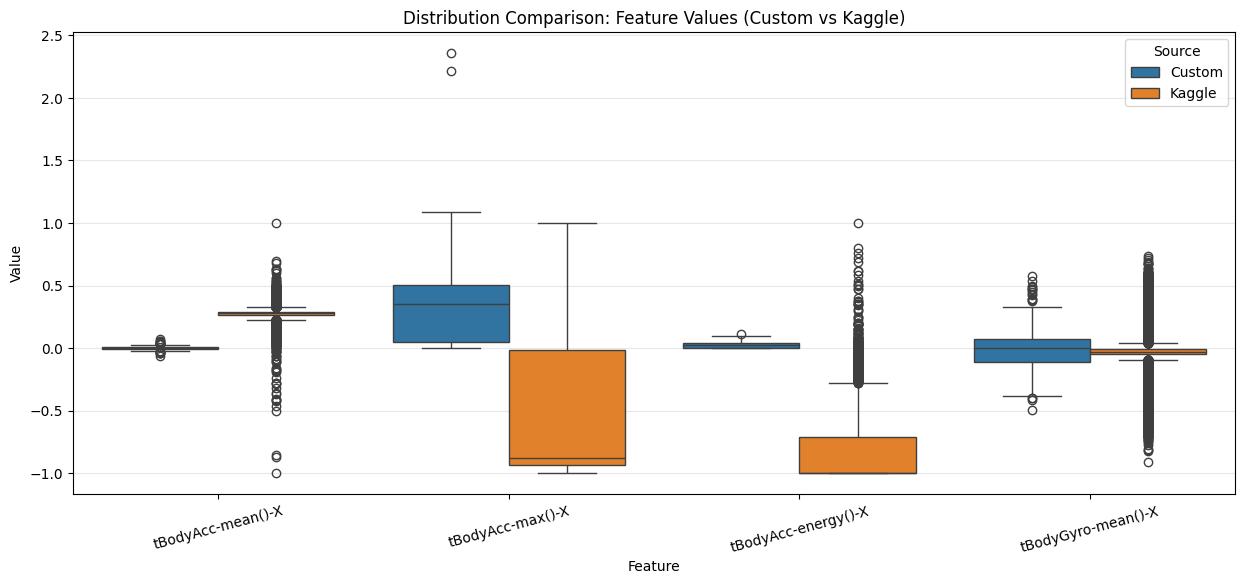

--- Custom Data Stats ---
      tBodyAcc-mean()-X  tBodyAcc-max()-X  tBodyAcc-energy()-X  \
min           -0.066547          0.002743             0.000001   
mean           0.000305          0.335067             0.025179   
max            0.069753          2.357795             0.112824   

      tBodyGyro-mean()-X  
min            -0.496484  
mean           -0.001515  
max             0.576992  

--- Kaggle Data Stats ---
      tBodyAcc-mean()-X  tBodyAcc-max()-X  tBodyAcc-energy()-X  \
min           -1.000000         -1.000000            -1.000000   
mean           0.274488         -0.468604            -0.820041   
max            1.000000          1.000000             1.000000   

      tBodyGyro-mean()-X  
min            -0.914050  
mean           -0.027184  
max             0.738953  


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Combine datasets for easier plotting, adding a 'Source' column
data_custom = data.copy()
data_custom['Source'] = 'Custom'

data_kaggle = kaggle_data_filtered.copy()
data_kaggle['Source'] = 'Kaggle'

# Select numeric columns only (excluding timestamp if present)
numeric_cols = data_custom.select_dtypes(include=[np.number]).columns.tolist()
if 'timestamp' in numeric_cols:
    numeric_cols.remove('timestamp')

# Sample a few key features to visualize
# tBodyAcc-mean()-X is a standard feature to check scaling
key_features = [
    'tBodyAcc-mean()-X', 
    'tBodyAcc-max()-X', 
    'tBodyAcc-energy()-X',
    'tBodyGyro-mean()-X'
]

# Provide a fallback if specific features aren't found
available_features = [f for f in key_features if f in numeric_cols]
if not available_features:
    available_features = numeric_cols[:4]

combined_df = pd.concat([data_custom, data_kaggle], ignore_index=True)

# 1. Box plots for distribution comparison
plt.figure(figsize=(15, 6))
data_to_plot = combined_df.melt(id_vars=['Source'], value_vars=available_features, var_name='Feature', value_name='Value')

sns.boxplot(data=data_to_plot, x='Feature', y='Value', hue='Source')
plt.title("Distribution Comparison: Feature Values (Custom vs Kaggle)")
plt.xticks(rotation=15)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# 2. Check Min/Max stats to confirm scaling difference
print("--- Custom Data Stats ---")
print(data_custom[available_features].describe().loc[['min', 'mean', 'max']])
print("\n--- Kaggle Data Stats ---")
print(data_kaggle[available_features].describe().loc[['min', 'mean', 'max']])
